<a href="https://colab.research.google.com/github/eddybanshuy/taller2_app_algoritmos_supervisador/blob/main/taller2_alg_supervisados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="width: 100%; clear: both;">
<div style="float: left; width: 30%;">
<img src="https://utpl.edu.ec/recursos/img/utpl2.png", align="left" width="280" height="120">
</div>
</div>
<div style="float: right; width: 70%;">
<p style="margin: 0; padding-top: 32px; text-align:right; color:#003366; font-size:16px"><u>Métodos de Aprendizaje de Maquina</u></p>
<p style="margin: 0; text-align:right; color:#999999; font-size:17px">Maestría en Inteligencia Artificial Aplicada</p>
</div>
</div>
<div style="width: 100%; clear: both;">
<div style="width:100%;">&nbsp;</div>

# Taller 2: Aplicación de algoritmos supervisados



1.   Aplicar algoritmo árbol de decisión, utilice RandomizedSearchCV.

2.   Aplicar algoritmo RandomForest, utilice RandomizedSearchCV.

3.   Aplicar algoritmo KNN, utilice RandomizedSearchCV.

4.   Aplicar algoritmo SVM, utilice RandomizedSearchCV.

5.   Cada algoritmo debe tener su matriz de confusión y el reporte de las métricas precisión, recall, accuracy y F1-Score.




Cargar dataset y librerias

In [33]:
# Librerias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC



In [34]:
# Cargar dataset y realizar
data = pd.read_csv("winequality-redLabel.csv", sep=";")

#Copia del Dataset para los Algoritmos
data_randonF = data.copy()
data_knn = data.copy()
data_svm = data.copy()

In [35]:
#Verificamos la data si esta correctamente cargada
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,8.6,0.315,0.40,2.2,0.079,3.0,6.0,0.99512,3.27,0.67,11.9,medium
1,12.2,0.450,0.49,1.4,0.075,3.0,6.0,0.99690,3.13,0.63,10.4,low
2,12.2,0.450,0.49,1.4,0.075,3.0,6.0,0.99690,3.13,0.63,10.4,low
3,8.0,0.600,0.08,2.6,0.056,3.0,7.0,0.99286,3.22,0.37,13.0,low
4,8.0,0.580,0.16,2.0,0.120,3.0,7.0,0.99454,3.22,0.58,11.2,medium


# Aplicar algoritmo árbol de decisión, utilice RandomizedSearchCV

**A continuacion realizo el entrenamiento con un 70% y de prueba 30%**

In [37]:
# Realizamos las separaciones de variables predictoras "X" y la variable objetivo "Y"
X = data.drop("quality", axis=1)
y = data["quality"]

# Dividimos en train/test, realizo un 70% de entrenamiento y un 30% de prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y)

# Definir el modelo y los parametros para la busqueda aleatoria
dt = DecisionTreeClassifier(random_state=42)

param_dist = {
    "criterion": ["gini", "entropy"],
    "max_depth": np.arange(2, 20),
    "min_samples_split": np.arange(2, 20),
    "min_samples_leaf": np.arange(1, 20)
}


In [38]:
#Realizamos " RandomizedSearchCV "
random_search = RandomizedSearchCV(
    dt,
    param_distributions=param_dist,
    n_iter=50,  # numero de combinaciones aleatorias
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# Mejor modelo
best_dt = random_search.best_estimator_

# Realizamos las Predicciones
y_pred = best_dt.predict(X_test)


In [40]:
# Verifico, imprimiendo las metricas
print("Mejores parametros:", random_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))



Mejores parametros: {'min_samples_split': np.int64(14), 'min_samples_leaf': np.int64(12), 'max_depth': np.int64(6), 'criterion': 'entropy'}
Accuracy: 0.7320675105485233

Reporte de clasificación:
               precision    recall  f1-score   support

        high       0.00      0.00      0.00         5
         low       0.70      0.78      0.74       221
      medium       0.76      0.71      0.73       248

    accuracy                           0.73       474
   macro avg       0.49      0.49      0.49       474
weighted avg       0.73      0.73      0.73       474



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


como resultado tenemos un nivel de precision 0,73

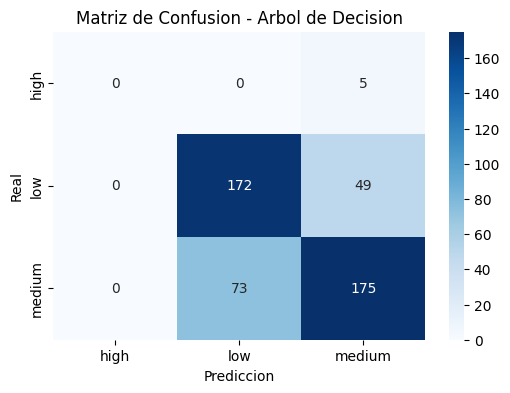

In [42]:
# Matriz de confusion de RandomizedSearchCV
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de Confusion - Arbol de Decision")
plt.show()

Como interpretacion de la matriz tenemos que la

*   Clase high tenemos 0 aciertos y 5 errores en "medium"
*   Clase low tenemos 172 aciertos, pero 49 fueron confundidos en "medium"
*   Clase medium tenemos 175 aciertos, aunque 73 fueron confundidos en "low"


Recordemos que aplicamos el algoritmo Arbol de Decision


# Aplicar algoritmo RandomForest, utilice RandomizedSearchCV.

In [43]:
# Separamos las variables predictoras "X" y la variable objetivo "Y"
X = data_randonF.drop("quality", axis=1)
y = data_randonF["quality"]

# Dividimos en train/test tenemos 70% para entrenamiento y  30% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3,
    random_state=42,
    stratify=y
)


In [44]:
# Realizamos el modelo y parametros para la busqueda aleatoria
rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": np.arange(50, 300, 50),   # numero de arboles
    "max_depth": np.arange(5, 30, 5),         # profundidad maxima
    "min_samples_split": np.arange(2, 20),    # minimo de muestras para dividir
    "min_samples_leaf": np.arange(1, 20),     # minimo de muestras en hoja
    "bootstrap": [True, False]                # muestreo con reemplazo
}

# RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=50,   # numero de combinaciones aleatorias
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)

# Mejor modelo
best_rf = random_search_rf.best_estimator_

# Realizamos las predicciones
y_pred_rf = best_rf.predict(X_test)

In [45]:
# Realizamos la evaluacion, con las metricas de valuacion
print("Mejores parametros:", random_search_rf.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_rf))

Mejores parametros: {'n_estimators': np.int64(50), 'min_samples_split': np.int64(7), 'min_samples_leaf': np.int64(4), 'max_depth': np.int64(10), 'bootstrap': False}
Accuracy: 0.7932489451476793

Reporte de clasificación:
               precision    recall  f1-score   support

        high       0.00      0.00      0.00         5
         low       0.79      0.80      0.79       221
      medium       0.80      0.81      0.80       248

    accuracy                           0.79       474
   macro avg       0.53      0.53      0.53       474
weighted avg       0.78      0.79      0.79       474



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


tenemos una precicion de 0,79

Text(0.5, 1.0, 'Matriz de Confusion - RandomForest')

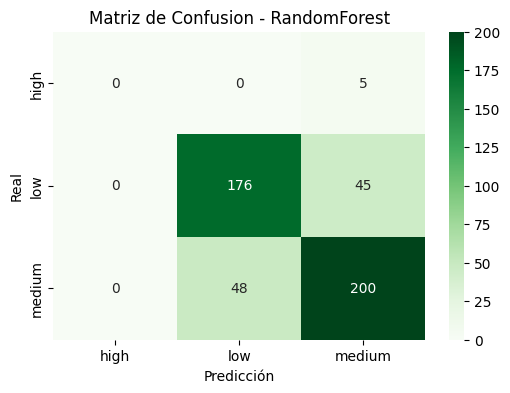

In [19]:
# Realizamos la matriz de confucion
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusion - RandomForest")

omo interpretacion de la matriz tenemos que la

*   Clase high tenemos 0 aciertos y 5 errores en "medium"
*   Clase low tenemos 176 aciertos, pero 45 fueron confundidos en "medium"
*   Clase medium tenemos 200 aciertos, aunque 48 fueron confundidos en "low"


Recordemos que aplicamos el algoritmo RandomForest


# Aplicar algoritmo KNN, utilice RandomizedSearchCV.

In [47]:
# Separamos las variables predictoras "X" y la variable objetivo "y"
X = data_knn.drop("quality", axis=1)
y = data_knn["quality"]

# Realizamos la divicion en train/test de 70% entrenamiento y 30% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Creamos el pipeline con escalado + KNN
pipeline = Pipeline([
    ("scaler", StandardScaler()),       # normalizamos los datos
    ("knn", KNeighborsClassifier())
])

In [48]:
# Definimos los parametros para busqueda aleatoria
param_dist = {
    "knn__n_neighbors": np.arange(3, 30),          # numero de vecinos
    "knn__weights": ["uniform", "distance"],       # tipo de ponderacion
    "knn__metric": ["euclidean", "manhattan", "minkowski"]  # metricas de distancia
}

# RandomizedSearchCV
random_search_knn = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=30,   # número de combinaciones aleatorias
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search_knn.fit(X_train, y_train)

# Mejor modelo
best_knn = random_search_knn.best_estimator_

# Realizamos las predicciones
y_pred_knn = best_knn.predict(X_test)

In [49]:
# Realizamos las evaluaciones
print("Mejores parametros:", random_search_knn.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nReporte de clasificacion:\n", classification_report(y_test, y_pred_knn))


Mejores parametros: {'knn__weights': 'distance', 'knn__n_neighbors': np.int64(26), 'knn__metric': 'manhattan'}
Accuracy: 0.7953586497890295

Reporte de clasificacion:
               precision    recall  f1-score   support

        high       0.00      0.00      0.00         5
         low       0.79      0.79      0.79       221
      medium       0.80      0.81      0.81       248

    accuracy                           0.80       474
   macro avg       0.53      0.54      0.53       474
weighted avg       0.79      0.80      0.79       474



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


tenemos como resultado en precision 0,80

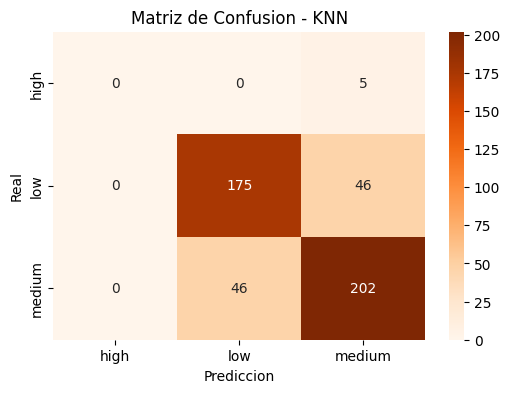

In [50]:
# Realizamos la matriz de confusion
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de Confusion - KNN")
plt.show()

omo interpretacion de la matriz tenemos que la

*   Clase high tenemos 0 aciertos y 5 errores en "medium"
*   Clase low tenemos 175 aciertos, pero 46 fueron confundidos en "medium"
*   Clase medium tenemos 202 aciertos, aunque 46 fueron confundidos en "low"


Recordemos que aplicamos el algoritmo KNN


# Aplicar algoritmo SVM, utilice RandomizedSearchCV

In [51]:
# Separamos las  variables predictoras "X" y la variable objetivo "y"
X = data_svm.drop("quality", axis=1)
y = data_svm["quality"]

# Realizamos las divisiones en train/test de 70% de entrenamiento y 30% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3,
    random_state=42,
    stratify=y
)

# Creamos el pipeline con escalado + SVM
pipeline = Pipeline([
    ("scaler", StandardScaler()),   # normaliza los datos
    ("svm", SVC())
])

In [52]:
# Realizamos las deficiones de parametros para la busqueda aleatoria
param_dist = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": [0.001, 0.01, 0.1],
    "svm__kernel": ["linear", "rbf"]
}

# Realizamos RandomizedSearchCV
random_search_svm = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=10,   # combinaciones
    cv=3,        # folds
    random_state=42,
    n_jobs=-1
)




random_search_svm.fit(X_train, y_train)

# Mejor modelo
best_svm = random_search_svm.best_estimator_

# Realizamos las Predicciones
y_pred_svm = best_svm.predict(X_test)


In [53]:
# Realizamos las evaluaciones
print("Mejores parámetros:", random_search_svm.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_svm))


Mejores parámetros: {'svm__kernel': 'rbf', 'svm__gamma': 0.01, 'svm__C': 10}
Accuracy: 0.7468354430379747

Reporte de clasificación:
               precision    recall  f1-score   support

        high       0.00      0.00      0.00         5
         low       0.72      0.78      0.75       221
      medium       0.77      0.73      0.75       248

    accuracy                           0.75       474
   macro avg       0.50      0.50      0.50       474
weighted avg       0.74      0.75      0.74       474



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


como resultado tenemos una presion de 0,75

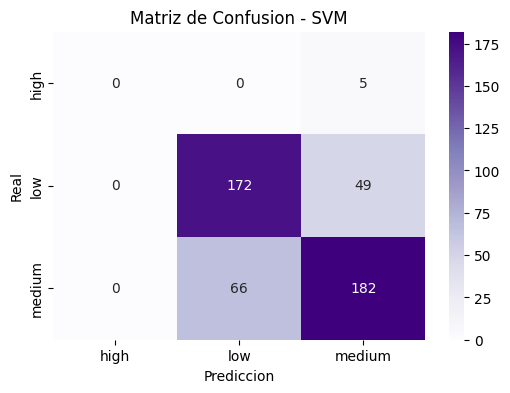

In [54]:
# Imprimir la matrix de confusion
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de Confusion - SVM")
plt.show()

omo interpretacion de la matriz tenemos que la

*   Clase high tenemos 0 aciertos y 5 errores en "medium"
*   Clase low tenemos 172 aciertos, pero 49 fueron confundidos en "medium"
*   Clase medium tenemos 182 aciertos, aunque 66 fueron confundidos en "low"


Recordemos que aplicamos el algoritmo SVM



**GitHub**

https://github.com/eddybanshuy/taller2_app_algoritmos_supervisador.git
